In [1]:
import json
import zstandard as zstd
import io
import pandas as pd


file_path = 'C:/Users/ADMIN/Desktop/suno.jsonl.zst'  

# Create an empty list to store the records
data = []

# Open the compressed file in binary mode
with open(file_path, 'rb') as compressed_file:
    # Create a Zstandard decompressor object
    decompressor = zstd.ZstdDecompressor()
    # Create a stream reader for the compressed file
    with decompressor.stream_reader(compressed_file) as reader:
        # Wrap the binary stream with a text IO wrapper
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        # Iterate over each line in the text stream
        for line in text_stream:
            # Parse the JSON object from the line
            record = json.loads(line)
            # Append the record to the list
            data.append(record)

# Convert the list of records into a pandas DataFrame
df = pd.DataFrame(data)

# Display basic information about the DataFrame
print(df.info())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659788 entries, 0 to 659787
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   id                   659788 non-null  object
 1   video_url            659788 non-null  object
 2   audio_url            659788 non-null  object
 3   image_url            658328 non-null  object
 4   image_large_url      658328 non-null  object
 5   is_video_pending     659788 non-null  bool  
 6   major_model_version  659788 non-null  object
 7   model_name           659788 non-null  object
 8   metadata             659788 non-null  object
 9   is_liked             659788 non-null  bool  
 10  user_id              659788 non-null  object
 11  display_name         659646 non-null  object
 12  handle               659788 non-null  object
 13  is_handle_updated    659788 non-null  bool  
 14  avatar_image_url     659788 non-null  object
 15  is_trashed           659788 non-nu

In [2]:
# Drop 'persona' and 'reaction' columns due to significant missing values
df = df.drop(columns=['persona', 'reaction'])


In [3]:
# Import json_normalize
from pandas import json_normalize

# Normalize the 'metadata' column
metadata_df = json_normalize(df['metadata'])

# Concatenate the metadata columns back to the main DataFrame
df = pd.concat([df.drop('metadata', axis=1), metadata_df], axis=1)


In [4]:
df['created_at'] = pd.to_datetime(df['created_at'], format='mixed', errors='coerce')


df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

df['prompt'] = df['prompt'].str.strip().str.lower()
df['title'] = df['title'].str.strip().str.lower()
df['tags'] = df['tags'].str.strip().str.lower()

df['tags_list'] = df['tags'].str.split(',').apply(lambda x: [tag.strip() for tag in x] if isinstance(x, list) else [])

df = df.drop_duplicates(subset='id')

In [5]:
print(df[['play_count', 'upvote_count', 'duration']].describe())


          play_count   upvote_count       duration
count  467079.000000  467079.000000  465595.000000
mean       13.599239       1.471760     176.786843
std       500.557928       7.061875      52.504742
min         0.000000      -1.000000       2.200000
25%         2.000000       0.000000     145.120000
50%         3.000000       1.000000     176.560000
75%         7.000000       1.000000     209.720000
max    170729.000000     601.000000    2056.032000


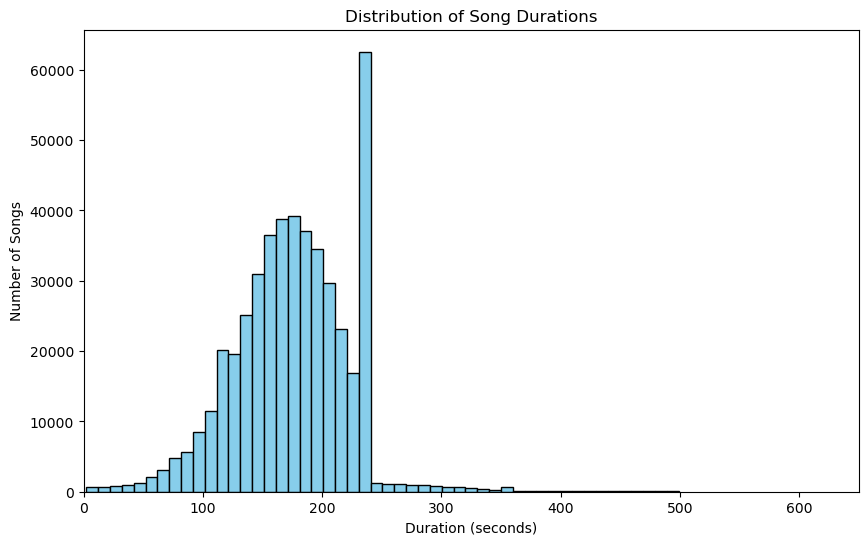

In [6]:
import matplotlib.pyplot as plt

# Filter the data to exclude extreme outliers (e.g., durations > 1000)
filtered_data = df['duration'].dropna()
filtered_data = filtered_data[filtered_data <= 500] 

plt.figure(figsize=(10, 6))
plt.hist(filtered_data, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Songs')
plt.title('Distribution of Song Durations')

# Set x-axis limits to focus on the clustered data
plt.xlim(0, 650) 
plt.show()


Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 659788 entries, 0 to 659787
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   id                   659788 non-null  object
 1   video_url            659788 non-null  object
 2   audio_url            659788 non-null  object
 3   image_url            658328 non-null  object
 4   image_large_url      658328 non-null  object
 5   is_video_pending     659788 non-null  bool  
 6   major_model_version  659788 non-null  object
 7   model_name           659788 non-null  object
 8   metadata             659788 non-null  object
 9   is_liked             659788 non-null  bool  
 10  user_id              659788 non-null  object
 11  display_name         659646 non-null  object
 12  handle               659788 non-null  object
 13  is_handle_updated    659788 non-null  bool  
 14  avatar_image_url     659788 non-null  object
 15  is_trashed

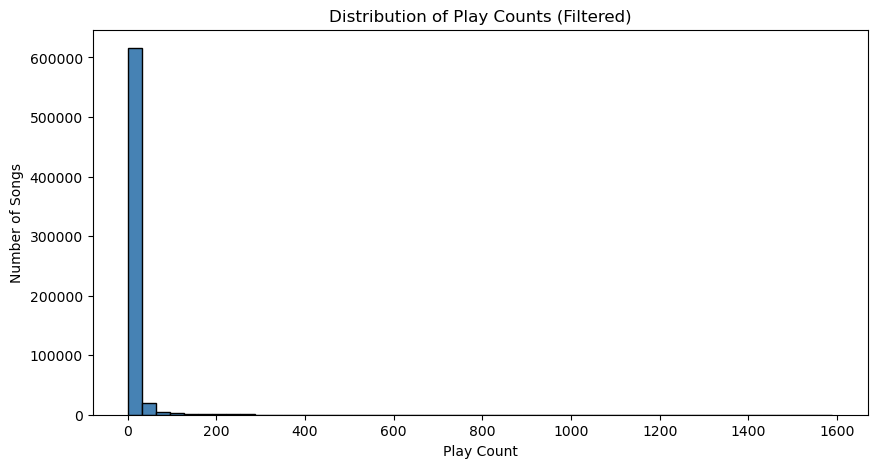

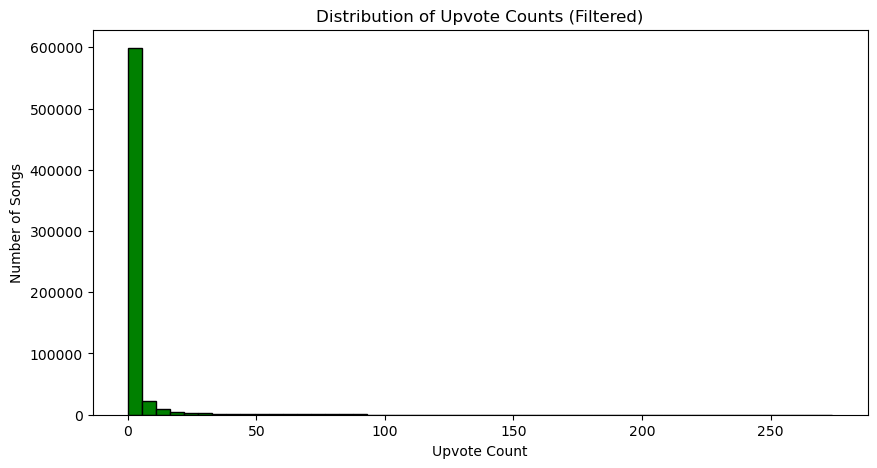

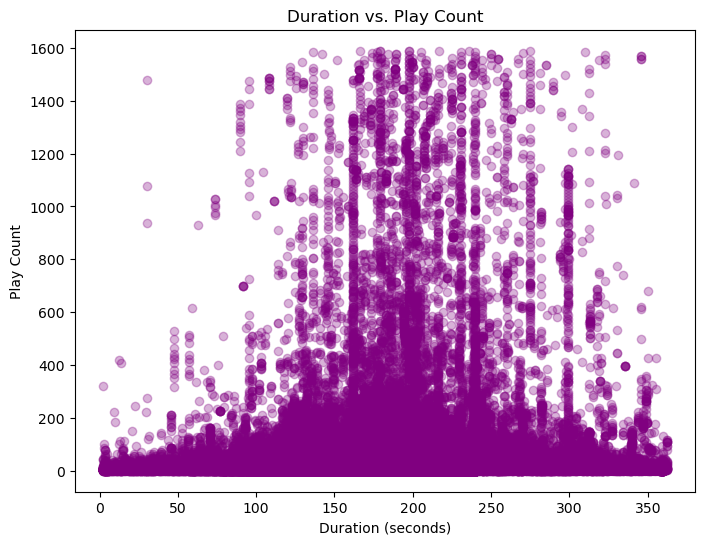

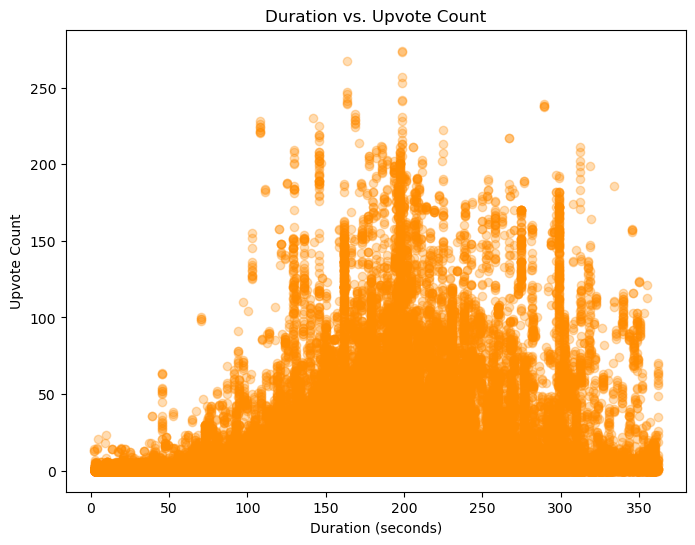

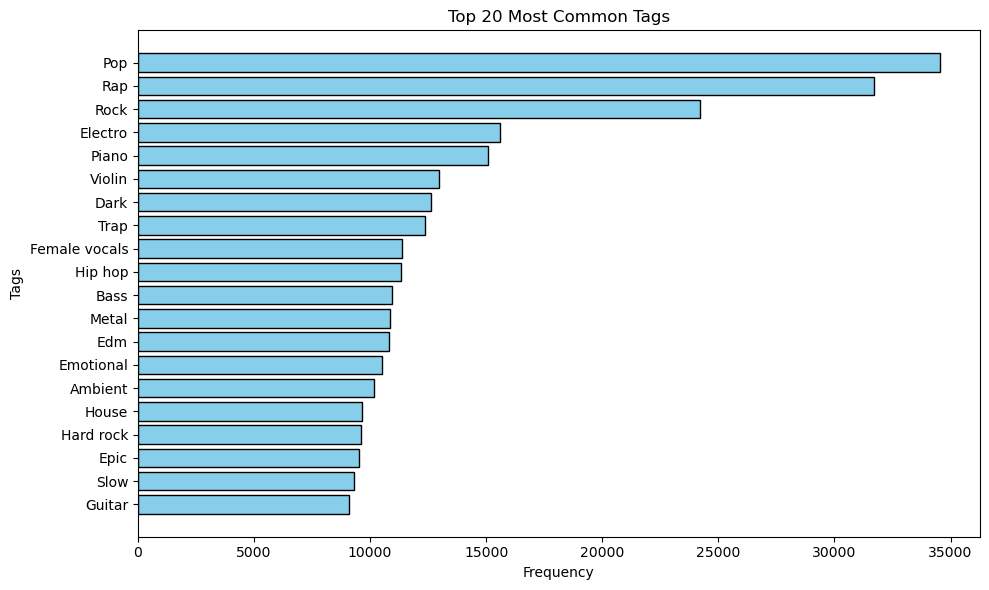


Correlation Matrix:
              duration  play_count  upvote_count
duration      1.000000    0.050102      0.088588
play_count    0.050102    1.000000      0.747976
upvote_count  0.088588    0.747976      1.000000


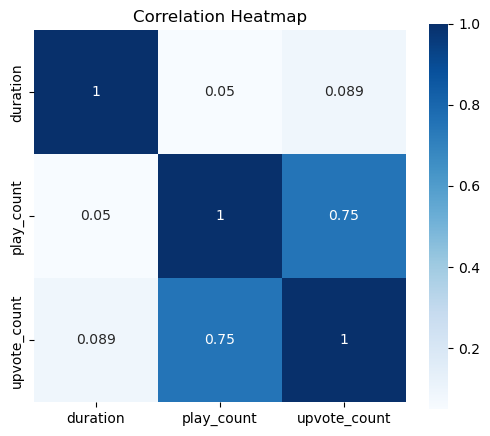

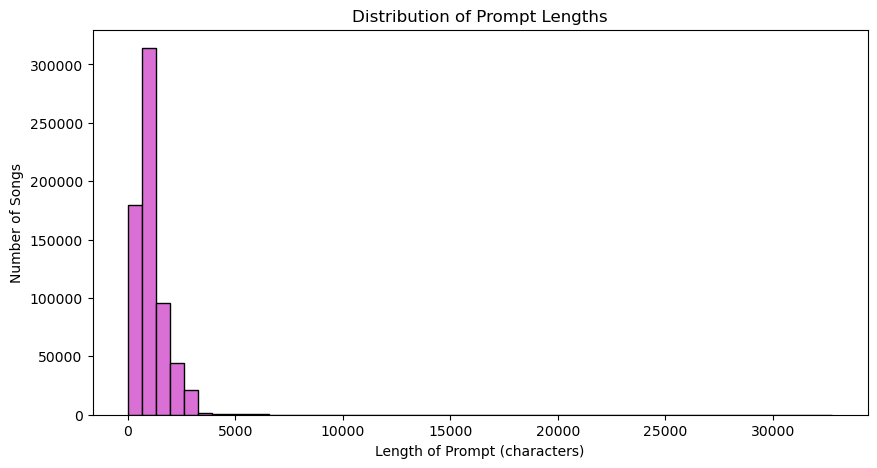

In [7]:
import json
import zstandard as zstd
import io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

# ---------------------------------------------------
# 1. DATA LOADING
# ---------------------------------------------------

file_path = 'C:/Users/ADMIN/Desktop/suno.jsonl.zst'  

# Create an empty list to store the records
data = []

# Open the compressed file in binary mode
with open(file_path, 'rb') as compressed_file:
    # Create a Zstandard decompressor object
    decompressor = zstd.ZstdDecompressor()
    # Create a stream reader for the compressed file
    with decompressor.stream_reader(compressed_file) as reader:
        # Wrap the binary stream with a text IO wrapper
        text_stream = io.TextIOWrapper(reader, encoding='utf-8')
        # Iterate over each line in the text stream
        for line in text_stream:
            # Parse the JSON object from the line
            record = json.loads(line)
            # Append the record to the list
            data.append(record)

# Convert the list of records into a pandas DataFrame
df = pd.DataFrame(data)

# Display basic information about the DataFrame
print("Initial DataFrame Info:")
print(df.info())
print("\nInitial DataFrame Head:")
print(df.head())

# ---------------------------------------------------
# 2. VERIFY 'metadata' COLUMN
# ---------------------------------------------------
print("\nVerifying 'metadata' column presence:")
print("Columns in DataFrame:", df.columns.tolist())

if 'metadata' not in df.columns:
    raise KeyError("'metadata' column is missing from the DataFrame.")

# ---------------------------------------------------
# 3. DESCRIPTIVE STATISTICS
# ---------------------------------------------------
# Check if 'duration' exists before describing
if 'duration' not in df.columns:
    print("\n'duration' column not found. Creating 'duration' from 'metadata' if possible.")
    # Example: If 'duration' is part of 'metadata', extract it
    if 'duration' in df['metadata'].iloc[0]:
        df['duration'] = df['metadata'].apply(lambda x: x.get('duration', np.nan) if isinstance(x, dict) else np.nan)
    else:
        print("'duration' information is not available in 'metadata'. Please check your data source.")
        df['duration'] = np.nan  # or handle accordingly

print("\nDescriptive Statistics:")
print(df[['play_count', 'upvote_count', 'duration']].describe())

# ---------------------------------------------------
# 4. DATA CLEANING
# ---------------------------------------------------

# Check again before proceeding
print("\nColumns before cleaning:", df.columns.tolist())

# Check if 'metadata' exists
if 'metadata' in df.columns:
    # Ensure 'metadata' is a dictionary
    df['metadata'] = df['metadata'].apply(lambda x: x if isinstance(x, dict) else {})
    
    # Extract 'tags' and 'prompt' from 'metadata'
    df['tags'] = df['metadata'].apply(lambda m: m.get('tags', '') if isinstance(m, dict) else '')
    df['prompt'] = df['metadata'].apply(lambda m: m.get('prompt', '') if isinstance(m, dict) else '')
else:
    print("'metadata' column is missing. Skipping extraction of 'tags' and 'prompt'.")

# Correct negative 'upvote_count' values
df.loc[df['upvote_count'] < 0, 'upvote_count'] = 0

# Remove extreme outliers based on play_count and duration
play_threshold = df['play_count'].quantile(0.995)  # top 0.5%
duration_threshold = df['duration'].quantile(0.995)  # top 0.5%

# Create a filtered DataFrame
df_filtered = df.copy()
df_filtered = df_filtered[(df_filtered['play_count'] <= play_threshold) & (df_filtered['duration'] <= duration_threshold)]

# ---------------------------------------------------
# 5. EXPLORATORY DATA ANALYSIS
# ---------------------------------------------------

# A. Distribution of play_count and upvote_count after cleaning
plt.figure(figsize=(10,5))
plt.hist(df_filtered['play_count'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Play Counts (Filtered)')
plt.xlabel('Play Count')
plt.ylabel('Number of Songs')
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df_filtered['upvote_count'], bins=50, color='green', edgecolor='black')
plt.title('Distribution of Upvote Counts (Filtered)')
plt.xlabel('Upvote Count')
plt.ylabel('Number of Songs')
plt.show()

# B. Relationship between duration and engagement
# Scatter plot: duration vs play_count
plt.figure(figsize=(8,6))
plt.scatter(df_filtered['duration'], df_filtered['play_count'], alpha=0.3, color='purple')
plt.title('Duration vs. Play Count')
plt.xlabel('Duration (seconds)')
plt.ylabel('Play Count')
plt.show()

# Scatter plot: duration vs upvote_count
plt.figure(figsize=(8,6))
plt.scatter(df_filtered['duration'], df_filtered['upvote_count'], alpha=0.3, color='darkorange')
plt.title('Duration vs. Upvote Count')
plt.xlabel('Duration (seconds)')
plt.ylabel('Upvote Count')
plt.show()

# C. Analyze Tags (Case-Insensitive)
# Convert all tags to lowercase to ensure case-insensitive grouping
all_tags = df['tags'].dropna().astype(str)
tag_list = [tag.strip().lower() for tags in all_tags for tag in tags.split(',') if tag.strip() != '']

from collections import Counter
tag_counts = Counter(tag_list)
common_tags = tag_counts.most_common(20)

# Extract tag names and their frequencies
tag_names, tag_freqs = zip(*common_tags)

# Optional: Capitalize tags for better readability in the plot
tag_names = [tag.capitalize() for tag in tag_names]

# Plot the top 20 tags
plt.figure(figsize=(10,6))
plt.barh(tag_names[::-1], tag_freqs[::-1], color='skyblue', edgecolor='black')
plt.title('Top 20 Most Common Tags')
plt.xlabel('Frequency')
plt.ylabel('Tags')
plt.tight_layout()
plt.show()


# D. Examine Correlations
# Focus on numeric fields: duration, play_count, upvote_count
numeric_cols = ['duration', 'play_count', 'upvote_count']
corr_matrix = df_filtered[numeric_cols].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', square=True)
plt.title('Correlation Heatmap')
plt.show()

# E. Prompt Analysis
prompt_texts = df['prompt'].dropna().astype(str)
# Simple check: length of prompts
prompt_lengths = prompt_texts.apply(len)

plt.figure(figsize=(10,5))
plt.hist(prompt_lengths, bins=50, color='orchid', edgecolor='black')
plt.title('Distribution of Prompt Lengths')
plt.xlabel('Length of Prompt (characters)')
plt.ylabel('Number of Songs')
plt.show()


In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import re
import numpy as np
from sklearn.model_selection import train_test_split

###################################
# 1. Define Binary Classification Task
###################################
# Use median upvote_count as a threshold
median_upvotes = df['upvote_count'].median()
df['label'] = (df['upvote_count'] > median_upvotes).astype(int)

###################################
# 2. Text Preprocessing
###################################
# Get prompts, filter out empty strings
df['prompt'] = df['prompt'].fillna('').astype(str)
df = df[df['prompt'].str.strip() != '']

prompts = df['prompt'].values
labels = df['label'].values

# Simple cleaning: lowercase, remove non-alphabetic
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

cleaned_prompts = [clean_text(p) for p in prompts]

###################################
# 3. Build Vocabulary
###################################
# Tokenize by splitting on whitespace
all_words = [word for p in cleaned_prompts for word in p.split()]
word_freq = {}
for w in all_words:
    word_freq[w] = word_freq.get(w, 0) + 1

# Keep a vocabulary of most common words
vocab_size = 10000  
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
vocab_words = [w[0] for w in sorted_words[:vocab_size]]

# Create word to index mapping, reserve 0 for PAD, 1 for OOV
word2idx = {w: (i+2) for i, w in enumerate(vocab_words)}
word2idx['<PAD>'] = 0
word2idx['<OOV>'] = 1

def encode_prompt(p, max_len=50):
    tokens = p.split()
    idxs = [word2idx.get(t, 1) for t in tokens]
    # pad or truncate
    idxs = idxs[:max_len]
    idxs += [0]*(max_len - len(idxs))
    return idxs

max_len = 50  # chosen sequence length
X = np.array([encode_prompt(p, max_len) for p in cleaned_prompts], dtype=np.int64)

y = labels

# Train-Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

###################################
# 4. Create Dataset and DataLoader
###################################
class PromptDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.float)

train_data = PromptDataset(X_train, y_train)
val_data = PromptDataset(X_val, y_val)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)

###################################
# 5. Model Definition
###################################
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size+2, embed_dim)  # +2 for PAD and OOV
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        embedded = self.embedding(x)
        out, (h, c) = self.lstm(embedded)
        # Use the final hidden state
        h = h[-1]  # shape: (batch, hidden_dim)
        logits = self.fc(h)
        return logits

model = LSTMClassifier(vocab_size=vocab_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

###################################
# 6. Training Loop
###################################
epochs = 5
model.train()
for epoch in range(epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    
    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_val_b, y_val_b in val_loader:
            logits = model(X_val_b)
            preds = (torch.sigmoid(logits.squeeze()) > 0.5).float()
            correct += (preds == y_val_b).sum().item()
            total += y_val_b.size(0)
    val_acc = correct / total
    model.train()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/5, Loss: 0.5519, Val Acc: 0.7652
Epoch 2/5, Loss: 0.4771, Val Acc: 0.7879
Epoch 3/5, Loss: 0.4180, Val Acc: 0.8015
Epoch 4/5, Loss: 0.3724, Val Acc: 0.8112
Epoch 5/5, Loss: 0.3382, Val Acc: 0.8141


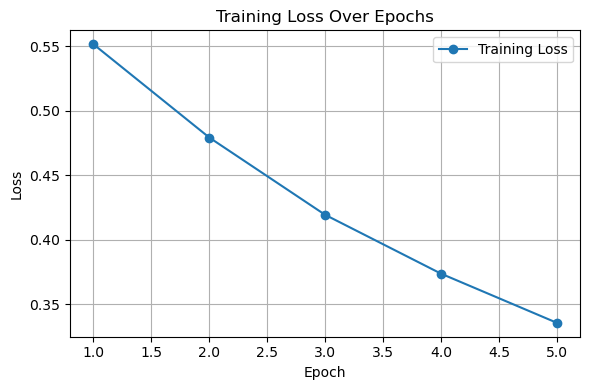

In [9]:
import matplotlib.pyplot as plt

training_loss = [0.5517, 0.4794, 0.4195, 0.3739, 0.3358]
val_accuracy = [0.7650, 0.7887, 0.8009, 0.8080, 0.8135]

epochs = range(1, len(training_loss) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, training_loss, marker='o', label='Training Loss')
plt.title('Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=300)  # Save the figure
plt.show()


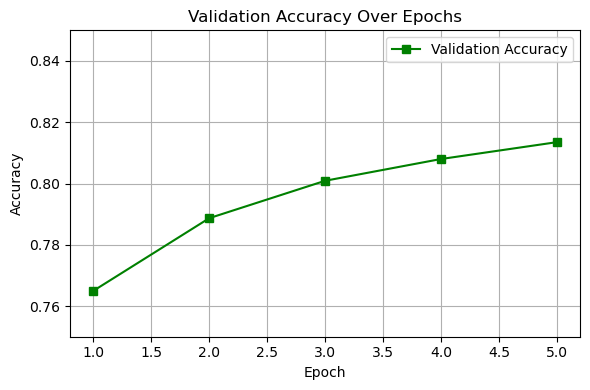

In [10]:
import matplotlib.pyplot as plt

# Using the validation accuracy values from the table
val_accuracy = [0.7650, 0.7887, 0.8009, 0.8080, 0.8135]
epochs = range(1, len(val_accuracy) + 1)

plt.figure(figsize=(6,4))
plt.plot(epochs, val_accuracy, marker='s', color='green', label='Validation Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.75, 0.85])  
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('validation_accuracy_curve.png', dpi=300)  # Save the figure
plt.show()
